In [ ]:
from inspect import FrameInfo
from google.colab import drive
drive.mount('/content/drive')

import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
import seaborn as sns
import requests
import xml.etree.ElementTree as ET
import pprint
import warnings
warnings.filterwarnings('ignore')

font_path = '/content/drive/MyDrive/kwukdt/seoul-bicycle-analysis/data/fonts/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
mpl.rc('font', family = 'NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
현재 폰트 :  ['NanumGothic']


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# https://www.kaggle.com/datasets/reihanenamdari/breast-cancer?select=Breast_Cancer.csv

In [ ]:
cancer = load_breast_cancer()

data_df = pd.DataFrame(cancer.data, columns = cancer.feature_names)
print('피처 수:', data_df.shape[1])
data_df.head()

피처 수: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
#소프트 보팅 기반 앙상블 구성
lr_clf = LogisticRegression(solver = 'liblinear', random_state = 156) #로지스틱 회귀 분류기 객체 생성
knn_clf = KNeighborsClassifier(n_neighbors = 8) # K - 최접근 이웃 분류기 객체

vo_clf = VotingClassifier(# 보팅 클래시파이어 객체
         estimators = [('LR', lr_clf), ('KNN', knn_clf)], #앙상블에 사용할 개별 모델 리스트
        voting = 'soft' #보팅 방식 ( hard or soft)
        )
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size = 0.2, random_state=156)

#보팅 앙상블 학습/평가
vo_clf.fit(X_train, y_train) #앙상블 모델 학습
pred= vo_clf.predict(X_test) #앙상블 모델 평가
print('Voting 분류기 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

#개별 모델 성능과 비교
print('\n[개별 모델 성능 비교]')
for clf in [lr_clf, knn_clf]:
  clf.fit(X_train, y_train)
  pred = clf.predict(X_test)
  print(f'{clf.__class__.__name__}:{accuracy_score(y_test, pred):.4f}')

Voting 분류기 정확도: 0.9561

[개별 모델 성능 비교]
LogisticRegression:0.9474
KNeighborsClassifier:0.9386


In [ ]:
#사용자 행동 인식 데이터로 실습
import numpy as np
# 중복 컬럼명 처리 함수
def get_new_feature_name_df(old_feature_name_df):
  feature_dup_df = pd.DataFrame(
      data = old_feature_name_df.groupby('column_name').cumcount(), # 각 그룹 내에서 중복 횟수를 카운트
      columns = ['dup_cnt'] #중복 횟수 칼럼의 이름

  )
  feature_dup_df = feature_dup_df.reset_index()
  new_feature_name_df = pd.merge(old_feature_name_df.reset_index(),feature_dup_df, how = 'outer')
  #중복 횟수가 0보다 크면 '원래이름_중복횟수', 아니면 ' 원래이름'
  new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(
      lambda x:x[0] + '_' + str(x[1] if x[1]> 0 else x[0], axis = 1)
  )
  new_feature_name_df = new_feature_name_df.drop(['index'], axis = 1) #컬럼 삭제
  return new_feature_name_df

In [ ]:
# https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones
# UCI 사용자 행동 인식 데이터셋을 로드

feature_name_df = pd.read_csv('/content/drive/MyDrive/KWU/ML/data/human_activity/features.txt', sep='\s+',
                              header=None, names=['column_index','column_name'])
feature_name_df

,column_index,column_name
0,1,tBodyAcc-mean()-X
1,2,tBodyAcc-mean()-Y
2,3,tBodyAcc-mean()-Z
3,4,tBodyAcc-std()-X
4,5,tBodyAcc-std()-Y
...,...,...
556,557,"angle(tBodyGyroMean,gravityMean)"
557,558,"angle(tBodyGyroJerkMean,gravityMean)"
558,559,"angle(X,gravityMean)"
559,560,"angle(Y,gravityMean)"


In [ ]:
feature_dup_df = pd.DataFrame(
    data=feature_name_df.groupby('column_name').cumcount(), #각 그룹 내에서 중복 횟수를 카운트
    columns=['dup_cnt'] # 중복 횟수 컬럼의 이름
)
feature_dup_df = feature_dup_df.reset_index()
feature_dup_df

,index,dup_cnt
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
556,556,0
557,557,0
558,558,0
559,559,0


In [ ]:
new_feature_name_df = pd.merge(feature_name_df.reset_index(),feature_dup_df, how='outer')
# 중복 횟수가 0보다 크면 '원래이름_중복횟수', 아니면 '원래이름'
new_feature_name_df['column_name'] = new_feature_name_df[['column_name','dup_cnt']].apply(
    lambda x: x[0]+'_'+str(x[1]) if x[1] > 0 else x[0], axis=1
)
new_feature_name_df = new_feature_name_df.drop(['index'], axis=1) # 컬럼 삭제
new_feature_name_df

,column_index,column_name,dup_cnt
0,1,tBodyAcc-mean()-X,0
1,2,tBodyAcc-mean()-Y,0
2,3,tBodyAcc-mean()-Z,0
3,4,tBodyAcc-std()-X,0
4,5,tBodyAcc-std()-Y,0
...,...,...,...
556,557,"angle(tBodyGyroMean,gravityMean)",0
557,558,"angle(tBodyGyroJerkMean,gravityMean)",0
558,559,"angle(X,gravityMean)",0
559,560,"angle(Y,gravityMean)",0


In [ ]:
feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
feature_name

['tBodyAcc-mean()-X',
 'tBodyAcc-mean()-Y',
 'tBodyAcc-mean()-Z',
 'tBodyAcc-std()-X',
 'tBodyAcc-std()-Y',
 'tBodyAcc-std()-Z',
 'tBodyAcc-mad()-X',
 'tBodyAcc-mad()-Y',
 'tBodyAcc-mad()-Z',
 'tBodyAcc-max()-X',
 'tBodyAcc-max()-Y',
 'tBodyAcc-max()-Z',
 'tBodyAcc-min()-X',
 'tBodyAcc-min()-Y',
 'tBodyAcc-min()-Z',
 'tBodyAcc-sma()',
 'tBodyAcc-energy()-X',
 'tBodyAcc-energy()-Y',
 'tBodyAcc-energy()-Z',
 'tBodyAcc-iqr()-X',
 'tBodyAcc-iqr()-Y',
 'tBodyAcc-iqr()-Z',
 'tBodyAcc-entropy()-X',
 'tBodyAcc-entropy()-Y',
 'tBodyAcc-entropy()-Z',
 'tBodyAcc-arCoeff()-X,1',
 'tBodyAcc-arCoeff()-X,2',
 'tBodyAcc-arCoeff()-X,3',
 'tBodyAcc-arCoeff()-X,4',
 'tBodyAcc-arCoeff()-Y,1',
 'tBodyAcc-arCoeff()-Y,2',
 'tBodyAcc-arCoeff()-Y,3',
 'tBodyAcc-arCoeff()-Y,4',
 'tBodyAcc-arCoeff()-Z,1',
 'tBodyAcc-arCoeff()-Z,2',
 'tBodyAcc-arCoeff()-Z,3',
 'tBodyAcc-arCoeff()-Z,4',
 'tBodyAcc-correlation()-X,Y',
 'tBodyAcc-correlation()-X,Z',
 'tBodyAcc-correlation()-Y,Z',
 'tGravityAcc-mean()-X',
 'tGravityA

In [ ]:
#학습/ 데스트 피치 데이터 (sep = 공백, 컬럼명 적용)
X_train = pd.read_csv('/content/drive/MyDrive/KWU/ML/data/human_activity/train/X_train.txt',sep='\s+', names = feature_name)
X_test = pd.read_csv('/content/drive/MyDrive/KWU/ML/data/human_activity/test/X_test.txt',sep='\s+', names = feature_name)

X_train = pd.read_csv('/content/drive/MyDrive/KWU/ML/data/human_activity/train/y_train.txt',sep='\s+', header = None, names = ['action'])
X_test = pd.read_csv('/content/drive/MyDrive/KWU/ML/data/human_activity/test/y_test.txt',sep='\s+', header = None, names = ['action'])

In [ ]:
print('학습셋:', X_train.shape,'테스트셋:', X_test.shape)

학습셋: (7352, 1) 테스트셋: (2947, 1)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train_features_human_activity = pd.read_csv('/content/drive/MyDrive/KWU/ML/data/human_activity/train/X_train.txt', sep='\s+', names=feature_name)
X_test_features_human_activity = pd.read_csv('/content/drive/MyDrive/KWU/ML/data/human_activity/test/X_test.txt', sep='\s+', names=feature_name)

# Use the variables that currently hold the human activity labels, which were incorrectly named X_train and X_test in cell 9nMzvvWCafSN.
# We will extract the single column to make them 1D Series/arrays as expected by scikit-learn.
y_train_human_activity = X_train.iloc[:, 0] # X_train in kernel state contains y_train.txt data
y_test_human_activity = X_test.iloc[:, 0]   # X_test in kernel state contains y_test.txt data


#기본 랜덤 포레스트 학습
rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(X_train_features_human_activity, y_train_human_activity) # Use the correct human activity features and labels
pred = rf_clf.predict(X_test_features_human_activity) # Predict using human activity test features
print('랜덤 포레스트 기본 정확도: {0:.4f}'.format(accuracy_score(y_test_human_activity, pred)))

랜덤 포레스트 기본 정확도: 0.9223


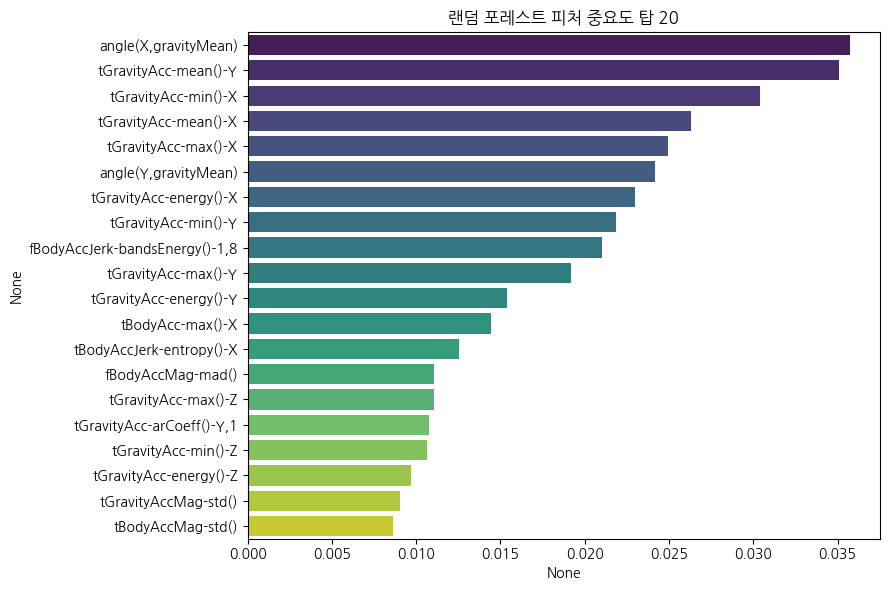

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported if not already

#피처 중요도 시각화
ftr_importances = pd.Series(
    rf_clf.feature_importances_,
    index = X_train_features_human_activity.columns # X_train_features_human_activity의 컬럼 사용
)
ftr_top20 = ftr_importances.sort_values(ascending = False)[:20] #피처 중요도 내림차순 정렬, 상위 20개 피처 선택

plt.figure(figsize = (9,6))
plt.title('랜덤 포레스트 피처 중요도 탑 20')
sns.barplot(x = ftr_top20, y = ftr_top20.index, palette='viridis')
plt.tight_layout() # 오타 수정
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
# GridSearchCV로 최적 하이퍼파라미터 탐색

params = {
    'n_estimators': [100],
    'max_depth': [6, 8, 10, 12],
    'min_samples_leaf': [8,12,18],
    'min_samples_split': [8,16,20]

}
rf_clf_gs = RandomForestClassifier(random_state=0, n_jobs=-1)
grid_cv = GridSearchCV(rf_clf_gs, param_grid = params, cv = 2, n_jobs = -1)
y_train_human_activity_reshaped = y_train_human_activity.values.ravel() #1차원 배열로 평탄화
grid_cv.fit(X_train_features_human_activity, y_train_human_activity_reshaped)

print('최적 하이퍼 파라미터:\n', grid_cv.best_params_)
print(f'최고 예측 정확도:{grid_cv.best_score_}')

최적 하이퍼 파라미터:
 {'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 100}
최고 예측 정확도:0.9178454842219804


In [ ]:
#최적 파라미터로 최종 학습
rf_clf1 = RandomForestClassifier(n_estimators = 300, #트리 개수를 300개
                                max_depth = 10,
                                min_samples_leaf = 8,
                                min_samples_split = 8,
                                random_state = 0,
                                )
y_train_human_activity_reshaped = y_train_human_activity.values.ravel()
rf_clf1.fit(X_train_features_human_activity, y_train_human_activity_reshaped)
pred = rf_clf1.predict(X_test_features_human_activity)
print(f'최적 파라미터 랜덤 포레스트 정확도: {accuracy_score(y_test_human_activity,pred)}')

최적 파라미터 랜덤 포레스트 정확도: 0.9165252799457075


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
import time

#사용자 행동 인식 데이터셋 사용
start_time = time.time()
gb_clf = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 0)
gb_clf.fit(X_train_features_human_activity,y_train_human_activity_reshaped)
gb_pred = gb_clf.predict(X_test_features_human_activity)

print(f'GBM 정확도: {accuracy_score(y_test_human_activity, gb_pred)}')
print(f'GBM 수행시간: {time.time() - start_time}') # start_time()을 start_time으로 수정
# 시간이 다소 많이 걸림

In [ ]:
params = {
    'n_estimators': [100, 500],
    'learning_rate': [0.05, 0.1]
}
gb_clf_gs = GradientBoostingClassifier(random_state=0)
grid_cv = GridSearchCV(gb_clf_gs, param_grid=params, cv=2, verbose=1) #verbose=1: 간단한 진행 상황 메세지를 출력
grid_cv.fit(X_train_features_human_activity, y_train_human_activity_reshaped)

print(' 최적 파라미터:',grid_cv.best_params_)
print(f'최고 예측 정확도: {grid_cv.best_score_}')

gb_pred = grid_cv.best_estimator_.predict(X_test) #best_estimator_ 속성에서 최적 모델을 가져와서
print(f'테스트셋 정확도: {accuracy_score(y_test_human_activity.gb_pred)}')